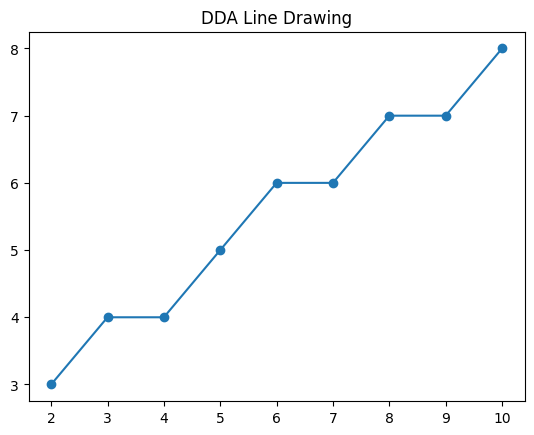

In [11]:
import matplotlib.pyplot as plt

def DDA(x1, y1, x2, y2):

    dx = x2 - x1
    dy = y2 - y1

    steps = max(abs(dx), abs(dy))

    x_inc = dx / steps
    y_inc = dy / steps

    x = x1
    y = y1

    x_points = []
    y_points = []

    for i in range(steps + 1):
        x_points.append(round(x))
        y_points.append(round(y))

        x = x + x_inc
        y = y + y_inc

    return x_points, y_points


# Example
x, y = DDA(2, 3, 10, 8)

plt.plot(x, y, marker='o')
plt.title("DDA Line Drawing")
plt.show()

In [ ]:
# Breshenhum Line drawing algorithm

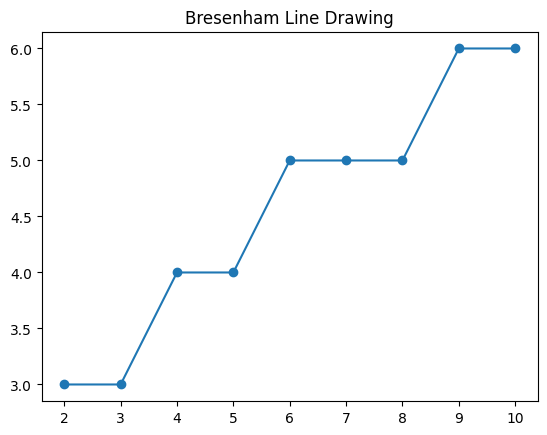

In [12]:
import matplotlib.pyplot as plt

def bresenham_line(x1, y1, x2, y2):

    dx = x2 - x1
    dy = y2 - y1

    p = 2*dy - dx

    x = x1
    y = y1

    x_points = []
    y_points = []

    while x <= x2:

        x_points.append(x)
        y_points.append(y)

        x = x + 1

        if p < 0:
            p = p + 2*dy
        else:
            y = y + 1
            p = p + 2*dy - 2*dx

    return x_points, y_points


# Example
x, y = bresenham_line(2, 3, 10, 6)

plt.plot(x, y, marker='o')
plt.title("Bresenham Line Drawing")
plt.show()

In [ ]:
# Breshenhum circle drawing algorithm

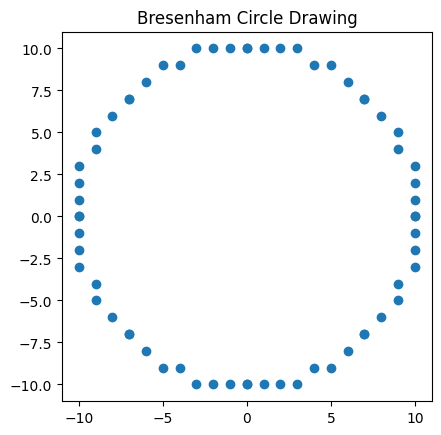

In [13]:
import matplotlib.pyplot as plt

def draw_circle(xc, yc, r):
    x = 0
    y = r
    d = 3 - 2 * r

    x_points = []
    y_points = []

    while x <= y:

        # 8-way symmetry points
        points = [
            (x, y),
            (y, x),
            (-x, y),
            (-y, x),
            (-x, -y),
            (-y, -x),
            (x, -y),
            (y, -x)
        ]

        # shift with center (xc, yc)
        for px, py in points:
            x_points.append(xc + px)
            y_points.append(yc + py)

        if d < 0:
            d = d + 4*x + 6
        else:
            d = d + 4*(x - y) + 10
            y -= 1

        x += 1

    return x_points, y_points


# Example
x, y = draw_circle(0, 0, 10)

plt.scatter(x, y)
plt.title("Bresenham Circle Drawing")
plt.gca().set_aspect('equal')
plt.show()

In [ ]:
# Transaltion

(7, 7)


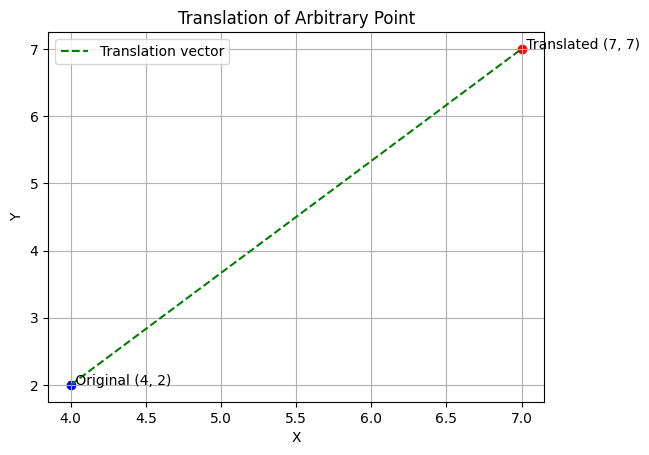

In [1]:
# Without homogenous
# Translation for Arbitrary Point with Figure
import matplotlib.pyplot as plt

#Translation for Arbitary point:
def translate(point, tx, ty):
    x, y = point
    return (x + tx, y + ty)

point = (4,2)
translated_point = translate(point, 3, 5)
print(translated_point)

# -------- Figure --------
plt.figure()

# points
plt.scatter(point[0], point[1], color='blue')
plt.scatter(translated_point[0], translated_point[1], color='red')

# line connecting points
plt.plot([point[0], translated_point[0]], [point[1], translated_point[1]], 'g--', label='Translation vector')

# labels
plt.text(point[0], point[1], f" Original {point}")
plt.text(translated_point[0], translated_point[1], f" Translated {translated_point}")

plt.title("Translation of Arbitrary Point")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()

Translated point (homogeneous): (7, 7)


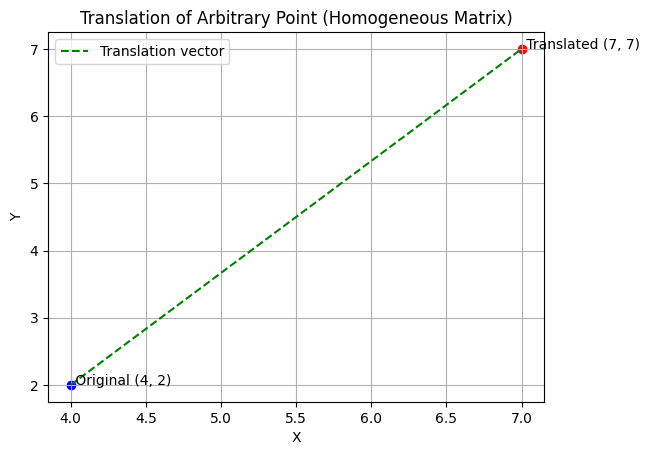

In [2]:
# With homogenous
# Translation for Arbitrary Point using Homogeneous Matrix with Figure
import numpy as np
import matplotlib.pyplot as plt

def to_homogenous(point):
    return np.array([[point[0]], [point[1]], [1]])

def from_homogenous(point):
    return (point[0][0], point[1][0])

def translate_homogenous(point, tx, ty):
    T = np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])
    p = to_homogenous(point)
    result = T @ p
    return from_homogenous(result)

# given values
point = (4, 2)
tx, ty = 3, 5

translated_point = translate_homogenous(point, tx, ty)
translated_point = (round(translated_point[0]), round(translated_point[1]))  # round figure

print("Translated point (homogeneous):", translated_point)

# -------- Figure --------
plt.figure()

# points
plt.scatter(point[0], point[1], color='blue')
plt.scatter(translated_point[0], translated_point[1], color='red')

# line connecting points (translation vector)
plt.plot([point[0], translated_point[0]], [point[1], translated_point[1]], 'g--', label='Translation vector')

# labels
plt.text(point[0], point[1], f" Original {point}")
plt.text(translated_point[0], translated_point[1], f" Translated {translated_point}")

plt.title("Translation of Arbitrary Point (Homogeneous Matrix)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Scalling

Scaled about arbitrary pivot: (7, 4)


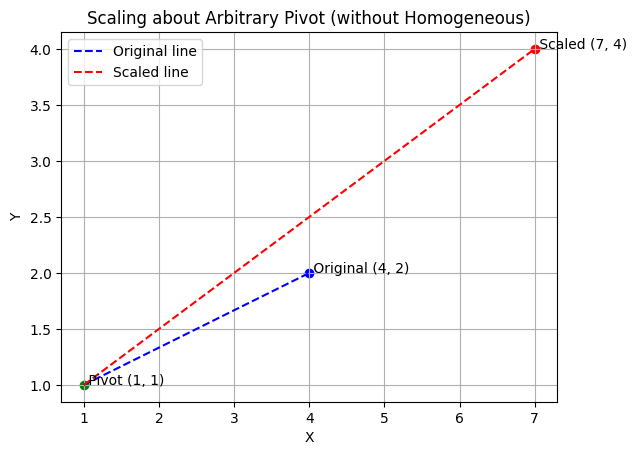

In [3]:
# Without Homogenous
# Scaling for Arbitrary Point without Homogeneous, with Figure
import matplotlib.pyplot as plt

# given values
point = (4,2)
pivot = (1,1)
sx, sy = 2, 3

x, y = point
px, py = pivot

# apply scaling formula
scaled_point = ((x - px) * sx + px, (y - py) * sy + py)
scaled_point = (round(scaled_point[0]), round(scaled_point[1]))

print("Scaled about arbitrary pivot:", scaled_point)

# -------- Figure --------
plt.figure()

# points
plt.scatter(x, y, color='blue')
plt.scatter(px, py, color='green')
plt.scatter(scaled_point[0], scaled_point[1], color='red')

# lines
plt.plot([px, x], [py, y], 'b--', label='Original line')
plt.plot([px, scaled_point[0]], [py, scaled_point[1]], 'r--', label='Scaled line')

# labels
plt.text(x, y, f" Original {point}")
plt.text(px, py, f" Pivot {pivot}")
plt.text(scaled_point[0], scaled_point[1], f" Scaled {scaled_point}")

plt.title("Scaling about Arbitrary Pivot (without Homogeneous)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()

Scaled about arbitrary pivot: (7, 4)


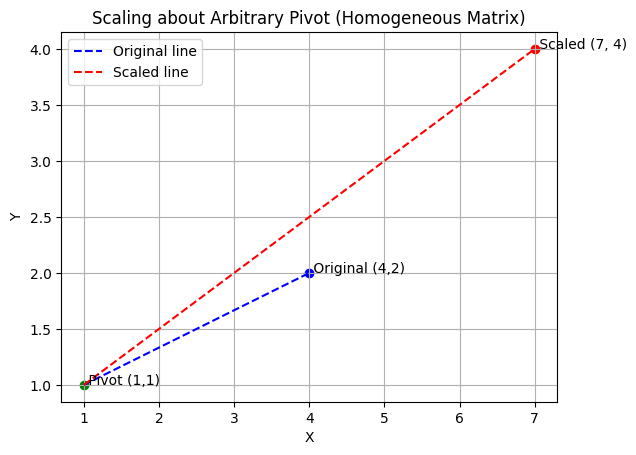

In [4]:
# With homogenous
# Scaling for Arbitrary Point with Figure (using Homogeneous Matrix)
import numpy as np
import matplotlib.pyplot as plt

def to_homogenous(point):
    return np.array([[point[0]], [point[1]], [1]])

def from_homogenous(point):
    return (round(point[0][0]), round(point[1][0]))

def scale_arbitrary(point, sx, sy, pivot):
    x_pivot, y_pivot = pivot

    # translate to origin
    T1 = np.array([[1,0,-x_pivot],
                   [0,1,-y_pivot],
                   [0,0,1]])
    # scaling matrix
    S  = np.array([[sx,0,0],
                   [0,sy,0],
                   [0,0,1]])
    # translate back
    T2 = np.array([[1,0,x_pivot],
                   [0,1,y_pivot],
                   [0,0,1]])

    p = to_homogenous(point)
    result = T2 @ S @ T1 @ p
    return from_homogenous(result)

# given values
point = (4,2)
pivot = (1,1)
sx, sy = 2, 3

scaled_point = scale_arbitrary(point, sx, sy, pivot)
print("Scaled about arbitrary pivot:", scaled_point)

# -------- Figure --------
plt.figure()

# points
plt.scatter(point[0], point[1], color='blue')
plt.scatter(pivot[0], pivot[1], color='green')
plt.scatter(scaled_point[0], scaled_point[1], color='red')

# lines
plt.plot([pivot[0], point[0]], [pivot[1], point[1]], 'b--', label='Original line')
plt.plot([pivot[0], scaled_point[0]], [pivot[1], scaled_point[1]], 'r--', label='Scaled line')

# labels
plt.text(point[0], point[1], " Original (4,2)")
plt.text(pivot[0], pivot[1], " Pivot (1,1)")
plt.text(scaled_point[0], scaled_point[1], f" Scaled {scaled_point}")

plt.title("Scaling about Arbitrary Pivot (Homogeneous Matrix)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Rotation

Rotated about arbitrary pivot: (0, 4)


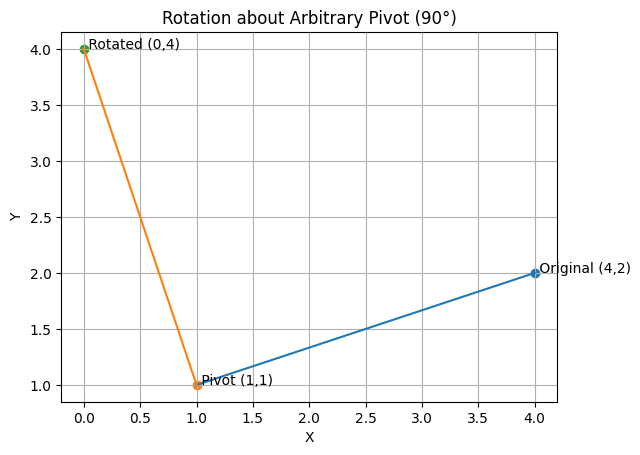

In [5]:
# without homogenous
# Easy Rotation for Arbitrary Point with Figure
import math
import matplotlib.pyplot as plt

# given values
point = (4, 2)
pivot = (1, 1)
angle = 90

# convert angle to radians
rad = math.radians(angle)

x, y = point
px, py = pivot

# translate point relative to pivot
tx = x - px
ty = y - py

# rotate
rx = tx * math.cos(rad) - ty * math.sin(rad)
ry = tx * math.sin(rad) + ty * math.cos(rad)

# translate back
rotated_point = (round(rx + px), round(ry + py))

print("Rotated about arbitrary pivot:", rotated_point)

# plotting
plt.scatter(x, y)
plt.scatter(px, py)
plt.scatter(rotated_point[0], rotated_point[1])

plt.plot([px, x], [py, y])
plt.plot([px, rotated_point[0]], [py, rotated_point[1]])

plt.text(x, y, " Original (4,2)")
plt.text(px, py, " Pivot (1,1)")
plt.text(rotated_point[0], rotated_point[1], " Rotated (0,4)")

plt.title("Rotation about Arbitrary Pivot (90°)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)

plt.show()

Rotated about arbitrary pivot: (0, 4)


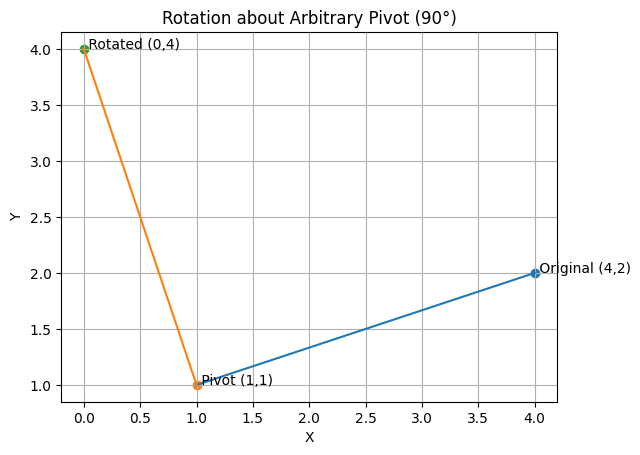

In [6]:
# With homogenous
# Rotation For Arbitrary point with Figure
import math
import numpy as np
import matplotlib.pyplot as plt

def to_homogenous(point):
    return np.array([[point[0]], [point[1]], [1]])

def from_homogenous(point):
    return (point[0][0], point[1][0])

def rotate_arbitrary(point, angle_degree, pivot):
    angle = math.radians(angle_degree)
    x_pivot, y_pivot = pivot

    T1 = np.array([
        [1, 0, -x_pivot],
        [0, 1, -y_pivot],
        [0, 0, 1]
    ])

    R = np.array([
        [math.cos(angle), -math.sin(angle), 0],
        [math.sin(angle),  math.cos(angle), 0],
        [0, 0, 1]
    ])

    T2 = np.array([
        [1, 0, x_pivot],
        [0, 1, y_pivot],
        [0, 0, 1]
    ])

    p = to_homogenous(point)
    result = T2 @ R @ T1 @ p
    return from_homogenous(result)

# given values
point = (4, 2)
pivot = (1, 1)
angle = 90

# rotation using homogeneous matrix
rotated_point = rotate_arbitrary(point, angle, pivot)

# round figure
rotated_point = (round(rotated_point[0]), round(rotated_point[1]))

print("Rotated about arbitrary pivot:", rotated_point)

# plotting figure
plt.figure()

# plot points
plt.scatter(point[0], point[1])
plt.scatter(pivot[0], pivot[1])
plt.scatter(rotated_point[0], rotated_point[1])

# draw lines
plt.plot([pivot[0], point[0]], [pivot[1], point[1]])
plt.plot([pivot[0], rotated_point[0]], [pivot[1], rotated_point[1]])

# labels
plt.text(point[0], point[1], " Original (4,2)")
plt.text(pivot[0], pivot[1], " Pivot (1,1)")
plt.text(rotated_point[0], rotated_point[1], " Rotated (0,4)")

plt.title("Rotation about Arbitrary Pivot (90°)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)

plt.show()

In [ ]:
# Reflection

Reflected about arbitrary pivot: (-2, 0)


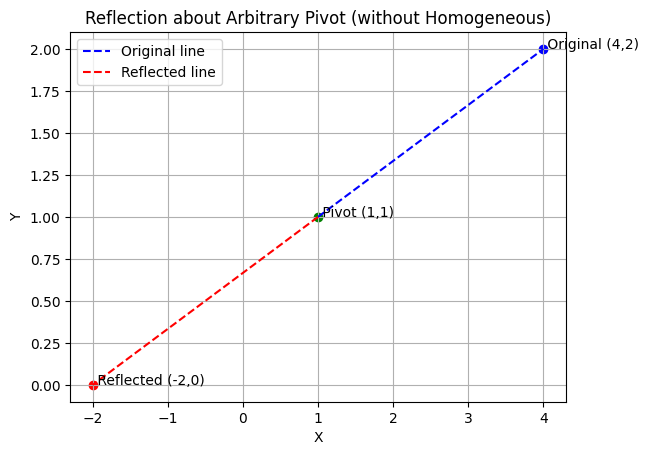

In [7]:
# Without homogenous
# Reflection for Arbitrary Point (without Homogeneous) with Figure
import matplotlib.pyplot as plt

# given values
point = (4, 2)
pivot = (1, 1)

x, y = point
px, py = pivot

# reflection formula
reflected_point = (2*px - x, 2*py - y)
reflected_point = (round(reflected_point[0]), round(reflected_point[1]))

print("Reflected about arbitrary pivot:", reflected_point)

# -------- Figure --------
plt.figure()

# points
plt.scatter(x, y, color='blue')
plt.scatter(px, py, color='green')
plt.scatter(reflected_point[0], reflected_point[1], color='red')

# lines
plt.plot([px, x], [py, y], 'b--', label='Original line')
plt.plot([px, reflected_point[0]], [py, reflected_point[1]], 'r--', label='Reflected line')

# labels
plt.text(x, y, " Original (4,2)")
plt.text(px, py, " Pivot (1,1)")
plt.text(reflected_point[0], reflected_point[1], " Reflected (-2,0)")

plt.title("Reflection about Arbitrary Pivot (without Homogeneous)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()

Reflected about arbitrary pivot: (-2, 0)


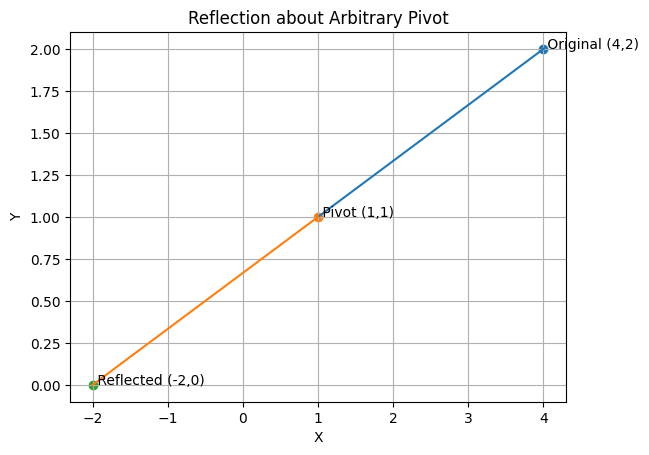

In [8]:
#With homogenous
# Reflection for Arbitrary Point with Figure
import numpy as np
import matplotlib.pyplot as plt

def to_homogenous(point):
    return np.array([[point[0]], [point[1]], [1]])

def from_homogenous(point):
    return (point[0][0], point[1][0])

def reflect_arbitrary(point, pivot):
    x_pivot, y_pivot = pivot

    T1 = np.array([
        [1, 0, -x_pivot],
        [0, 1, -y_pivot],
        [0, 0, 1]
    ])

    R = np.array([
        [-1, 0, 0],
        [0, -1, 0],
        [0, 0, 1]
    ])

    T2 = np.array([
        [1, 0, x_pivot],
        [0, 1, y_pivot],
        [0, 0, 1]
    ])

    p = to_homogenous(point)
    result = T2 @ R @ T1 @ p
    return from_homogenous(result)

# given values
point = (4, 2)
pivot = (1, 1)

reflected_point = reflect_arbitrary(point, pivot)

# round figure
reflected_point = (round(reflected_point[0]), round(reflected_point[1]))

print("Reflected about arbitrary pivot:", reflected_point)

# -------- Figure --------
plt.figure()

# points
plt.scatter(point[0], point[1])
plt.scatter(pivot[0], pivot[1])
plt.scatter(reflected_point[0], reflected_point[1])

# lines
plt.plot([pivot[0], point[0]], [pivot[1], point[1]])
plt.plot([pivot[0], reflected_point[0]], [pivot[1], reflected_point[1]])

# labels
plt.text(point[0], point[1], " Original (4,2)")
plt.text(pivot[0], pivot[1], " Pivot (1,1)")
plt.text(reflected_point[0], reflected_point[1], " Reflected (-2,0)")

plt.title("Reflection about Arbitrary Pivot")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)

plt.show()

In [ ]:
# Shearing

Sheared about arbitrary pivot: (5, 4)


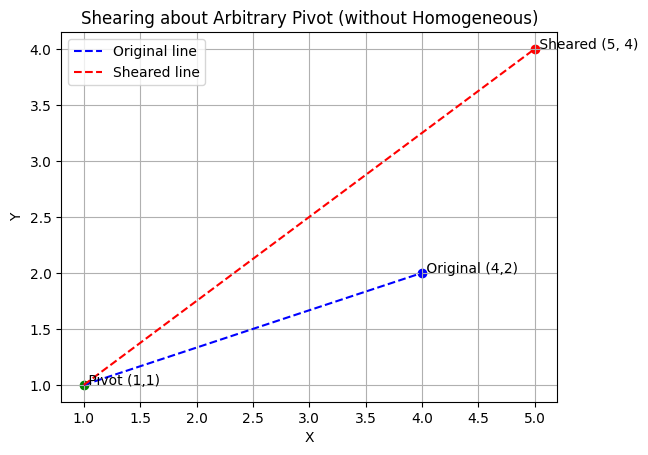

In [9]:
# Without homogenous
# Shearing for Arbitrary Point (without Homogeneous) with Figure
import matplotlib.pyplot as plt

# given values
point = (4, 2)
pivot = (1, 1)
shx = 1
shy = 0.5

x, y = point
px, py = pivot

# Step 1: translate to origin
tx = x - px
ty = y - py

# Step 2: apply shear
sx = tx + shx * ty
sy = shy * tx + ty

# Step 3: translate back
sheared_point = (round(sx + px), round(sy + py))

print("Sheared about arbitrary pivot:", sheared_point)

# -------- Figure --------
plt.figure()

# points
plt.scatter(x, y, color='blue')
plt.scatter(px, py, color='green')
plt.scatter(sheared_point[0], sheared_point[1], color='red')

# lines
plt.plot([px, x], [py, y], 'b--', label='Original line')
plt.plot([px, sheared_point[0]], [py, sheared_point[1]], 'r--', label='Sheared line')

# labels
plt.text(x, y, " Original (4,2)")
plt.text(px, py, " Pivot (1,1)")
plt.text(sheared_point[0], sheared_point[1], f" Sheared {sheared_point}")

plt.title("Shearing about Arbitrary Pivot (without Homogeneous)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()

Sheared about arbitrary pivot: (5, 4)


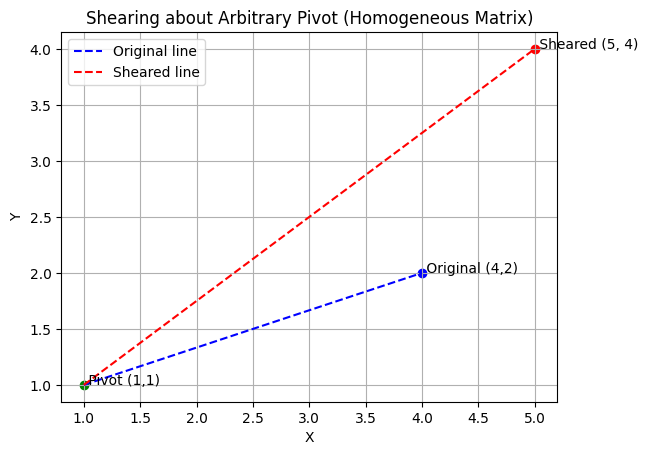

In [10]:
# With homogenous
# Shearing for Arbitrary Point with Figure (using homogeneous matrix)
import numpy as np
import matplotlib.pyplot as plt

def to_homogenous(point):
    return np.array([[point[0]], [point[1]], [1]])

def from_homogenous(point):
    return (point[0][0], point[1][0])

def shear_arbitrary(point, shx, shy, pivot):
    x_pivot, y_pivot = pivot

    T1 = np.array([
        [1, 0, -x_pivot],
        [0, 1, -y_pivot],
        [0, 0, 1]
    ])

    Sh = np.array([
        [1, shx, 0],
        [shy, 1, 0],
        [0, 0, 1]
    ])

    T2 = np.array([
        [1, 0, x_pivot],
        [0, 1, y_pivot],
        [0, 0, 1]
    ])

    p = to_homogenous(point)
    result = T2 @ Sh @ T1 @ p
    return from_homogenous(result)

# given values
point = (4, 2)
pivot = (1, 1)
shx = 1
shy = 0.5

# calculate sheared point
sheared_point = shear_arbitrary(point, shx, shy, pivot)

# round figure
sheared_point = (round(sheared_point[0]), round(sheared_point[1]))

print("Sheared about arbitrary pivot:", sheared_point)

# -------- Figure --------
plt.figure()

# points
plt.scatter(point[0], point[1], color='blue')
plt.scatter(pivot[0], pivot[1], color='green')
plt.scatter(sheared_point[0], sheared_point[1], color='red')

# lines
plt.plot([pivot[0], point[0]], [pivot[1], point[1]], 'b--', label='Original line')
plt.plot([pivot[0], sheared_point[0]], [pivot[1], sheared_point[1]], 'r--', label='Sheared line')

# labels
plt.text(point[0], point[1], " Original (4,2)")
plt.text(pivot[0], pivot[1], " Pivot (1,1)")
plt.text(sheared_point[0], sheared_point[1], f" Sheared {sheared_point}")

plt.title("Shearing about Arbitrary Pivot (Homogeneous Matrix)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Cohen sutherland line clipping algorithm

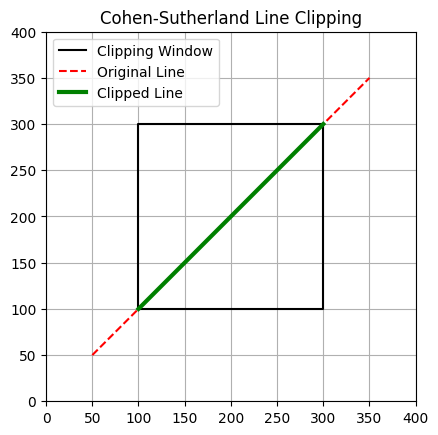

In [15]:
import matplotlib.pyplot as plt

# Region codes
INSIDE = 0
LEFT = 1
RIGHT = 2
BOTTOM = 4
TOP = 8

# Clipping window
xmin, ymin = 100, 100
xmax, ymax = 300, 300

def compute_code(x, y):
    code = INSIDE
    if x < xmin:
        code |= LEFT
    elif x > xmax:
        code |= RIGHT
    if y < ymin:
        code |= BOTTOM
    elif y > ymax:
        code |= TOP
    return code

def cohen_sutherland_clip(x1, y1, x2, y2):
    code1 = compute_code(x1, y1)
    code2 = compute_code(x2, y2)
    accept = False

    while True:
        if code1 == 0 and code2 == 0:
            accept = True
            break
        elif (code1 & code2) != 0:
            break
        else:
            code_out = code1 if code1 != 0 else code2

            if code_out & TOP:
                x = x1 + (x2 - x1) * (ymax - y1) / (y2 - y1)
                y = ymax
            elif code_out & BOTTOM:
                x = x1 + (x2 - x1) * (ymin - y1) / (y2 - y1)
                y = ymin
            elif code_out & RIGHT:
                y = y1 + (y2 - y1) * (xmax - x1) / (x2 - x1)
                x = xmax
            elif code_out & LEFT:
                y = y1 + (y2 - y1) * (xmin - x1) / (x2 - x1)
                x = xmin

            if code_out == code1:
                x1, y1 = x, y
                code1 = compute_code(x1, y1)
            else:
                x2, y2 = x, y
                code2 = compute_code(x2, y2)

    if accept:
        return x1, y1, x2, y2
    else:
        return None


# Original line
x1, y1 = 50, 50
x2, y2 = 350, 350

result = cohen_sutherland_clip(x1, y1, x2, y2)

# Plotting
plt.figure()

# Draw clipping window
plt.plot([xmin, xmax, xmax, xmin, xmin],
         [ymin, ymin, ymax, ymax, ymin],
         'k-', label="Clipping Window")

# Draw original line
plt.plot([x1, x2], [y1, y2], 'r--', label="Original Line")

# Draw clipped line
if result:
    cx1, cy1, cx2, cy2 = result
    plt.plot([cx1, cx2], [cy1, cy2], 'g-', linewidth=3, label="Clipped Line")

plt.xlim(0, 400)
plt.ylim(0, 400)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.title("Cohen-Sutherland Line Clipping")
plt.grid(True)
plt.show()

In [ ]:
# Sutherland hodgman polygon clipping algorithm

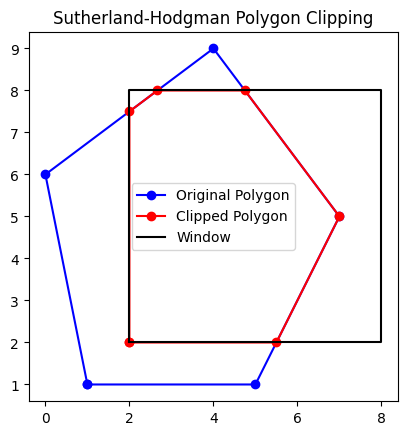

In [16]:
import matplotlib.pyplot as plt

# Clipping window
xmin, ymin, xmax, ymax = 2, 2, 8, 8

# Polygon vertices (example)
polygon = [(1,1), (5,1), (7,5), (4,9), (0,6)]


def inside(p, edge):
    x, y = p
    if edge == 'LEFT':
        return x >= xmin
    elif edge == 'RIGHT':
        return x <= xmax
    elif edge == 'BOTTOM':
        return y >= ymin
    elif edge == 'TOP':
        return y <= ymax


def intersection(p1, p2, edge):
    x1, y1 = p1
    x2, y2 = p2

    if x1 == x2:  # vertical line
        m = None
    else:
        m = (y2 - y1) / (x2 - x1)

    if edge == 'LEFT':
        x = xmin
        y = y1 + (xmin - x1) * m if m is not None else y1
    elif edge == 'RIGHT':
        x = xmax
        y = y1 + (xmax - x1) * m if m is not None else y1
    elif edge == 'BOTTOM':
        y = ymin
        x = x1 + (ymin - y1) / m if m is not None else x1
    elif edge == 'TOP':
        y = ymax
        x = x1 + (ymax - y1) / m if m is not None else x1

    return (x, y)


def clip_polygon(polygon, edge):
    clipped = []
    n = len(polygon)

    for i in range(n):
        curr = polygon[i]
        prev = polygon[i-1]

        if inside(curr, edge):
            if not inside(prev, edge):
                clipped.append(intersection(prev, curr, edge))
            clipped.append(curr)
        elif inside(prev, edge):
            clipped.append(intersection(prev, curr, edge))

    return clipped


# Apply clipping against all 4 edges
edges = ['LEFT', 'RIGHT', 'BOTTOM', 'TOP']
clipped_polygon = polygon[:]
for edge in edges:
    clipped_polygon = clip_polygon(clipped_polygon, edge)

# Plotting
# Original polygon
px, py = zip(*(polygon + [polygon[0]]))
plt.plot(px, py, 'b-o', label='Original Polygon')

# Clipped polygon
cx, cy = zip(*(clipped_polygon + [clipped_polygon[0]]))
plt.plot(cx, cy, 'r-o', label='Clipped Polygon')

# Clipping window
plt.plot([xmin, xmax, xmax, xmin, xmin],
         [ymin, ymin, ymax, ymax, ymin], 'k-', label='Window')

plt.title("Sutherland-Hodgman Polygon Clipping")
plt.legend()
plt.gca().set_aspect('equal')
plt.show()